In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.model_selection as skm
from sklearn.model_selection import GridSearchCV
from matplotlib.pyplot import subplots
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import PredictionErrorDisplay
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import (DecisionTreeClassifier as DTC,
DecisionTreeRegressor as DTR,
plot_tree,
export_text)
from sklearn.metrics import PredictionErrorDisplay
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.metrics import (accuracy_score,
confusion_matrix,
ConfusionMatrixDisplay,
mean_squared_error)
from sklearn.ensemble import \
(RandomForestRegressor as RF,
GradientBoostingRegressor as GBR)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


In [52]:
data = pd.read_csv("DANE.csv")
data.head()
print(data.describe())
print(data.info())
data

                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614      0.097456       0.054012   
std    21161.721625    22.612647      0.296607       0.226063   
min       67.000000     0.080000      0.000000       0.000000   
25%    17741.250000    25.000000      0.000000       0.000000   
50%    36932.000000    45.000000      0.000000       0.000000   
75%    54682.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level          bmi       stroke  
count        5110.000000  4909.000000  5110.000000  
mean          106.147677    28.893237     0.048728  
std            45.283560     7.854067     0.215320  
min            55.120000    10.300000     0.000000  
25%            77.245000    23.500000     0.000000  
50%            91.885000    28.100000     0.000000  
75%           114.090000    33.100000     0

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [53]:
data['bmi'] = data['bmi'].fillna(data['bmi'].median())
print(data.describe())
print(data.info())
data

                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614      0.097456       0.054012   
std    21161.721625    22.612647      0.296607       0.226063   
min       67.000000     0.080000      0.000000       0.000000   
25%    17741.250000    25.000000      0.000000       0.000000   
50%    36932.000000    45.000000      0.000000       0.000000   
75%    54682.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level          bmi       stroke  
count        5110.000000  5110.000000  5110.000000  
mean          106.147677    28.862035     0.048728  
std            45.283560     7.699562     0.215320  
min            55.120000    10.300000     0.000000  
25%            77.245000    23.800000     0.000000  
50%            91.885000    28.100000     0.000000  
75%           114.090000    32.800000     0

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,28.1,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [54]:
data = pd.get_dummies(data, columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'], drop_first=True, dtype=int)
data = data.drop(columns=['id'])
data.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,1,0,1,0,1,0,0,1,1,0,0
1,61.0,0,0,202.21,28.1,1,0,0,1,0,0,1,0,0,0,1,0
2,80.0,0,1,105.92,32.5,1,1,0,1,0,1,0,0,0,0,1,0
3,49.0,0,0,171.23,34.4,1,0,0,1,0,1,0,0,1,0,0,1
4,79.0,1,0,174.12,24.0,1,0,0,1,0,0,1,0,0,0,1,0


In [55]:
X = data.drop(columns=['stroke'])
y = data['stroke']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Treningowy: {X_train.shape}")
print(f"Testowy: {X_test.shape}")

Treningowy: (3577, 16)
Testowy: (1533, 16)


In [56]:
tree_model = DTC(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

Accuracy: 0.9491
Recall: 0.0133


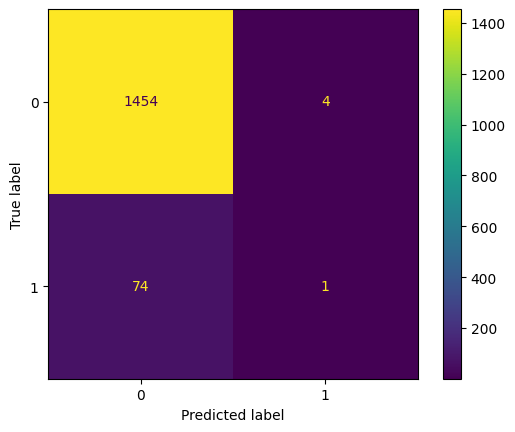

In [57]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tree):.4f}")
cm = confusion_matrix(y_test, y_pred_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [58]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

Accuracy: 0.9498
Recall: 0.0000


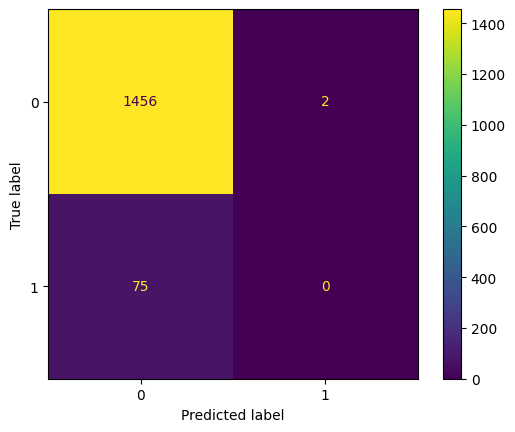

In [59]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

In [60]:
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

Accuracy: 0.9491
Recall: 0.0267


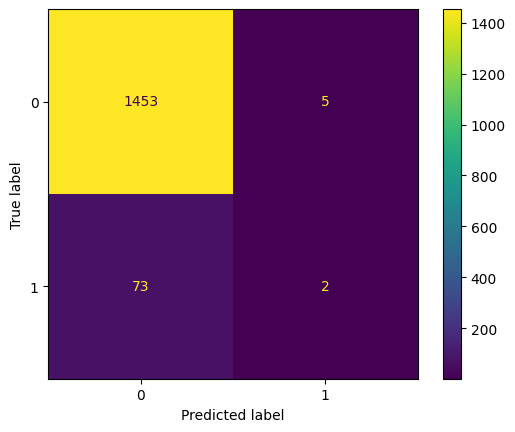

In [61]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_gb):.4f}")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb)
plt.show()

In [62]:
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

print(f"Rozmiar przed: {y_train.value_counts().to_dict()}")
print(f"Rozmiar po oversamplingu: {y_resampled.value_counts().to_dict()}")

Rozmiar przed: {0: 3403, 1: 174}
Rozmiar po oversamplingu: {0: 3403, 1: 3403}


In [63]:
param_grid_dt = {
    'max_depth': [3, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}
grid_dt = GridSearchCV(DTC(random_state=42), param_grid_dt, cv=3, scoring='recall', n_jobs=-1)
grid_dt.fit(X_resampled, y_resampled)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 5, 10]},
             scoring='recall')

In [64]:
param_grid_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring='recall', n_jobs=-1)
grid_rf.fit(X_resampled, y_resampled)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200, 300]},
             scoring='recall')

In [65]:

param_grid_gb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}


grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=3,
    scoring='recall',
    n_jobs=-1
)

grid_gb.fit(X_resampled, y_resampled)


GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [50, 100, 150]},
             scoring='recall')

Parametry: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1}
Accuracy: 0.9237
Recall: 0.1467


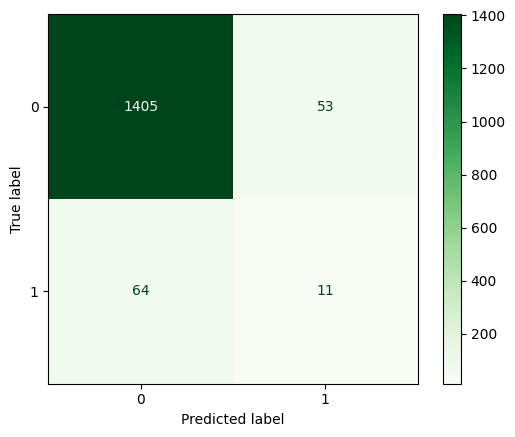

In [66]:
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

print(f"Parametry: {grid_dt.best_params_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, cmap='Greens')
plt.show()

Parametry: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Accuracy: 0.8780
Recall: 0.4267


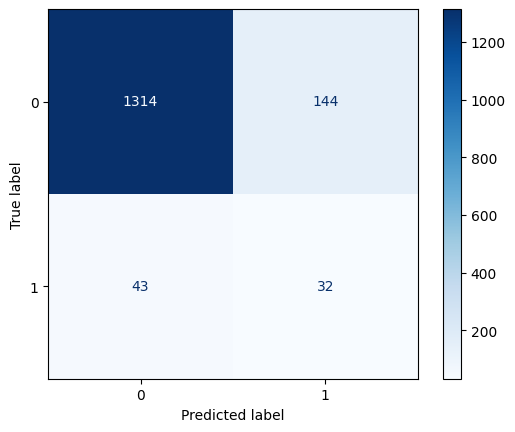

In [67]:
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)


print(f"Parametry: {grid_rf.best_params_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Blues')
plt.show()

Parametry: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Accuracy: 0.8891
Recall: 0.4400


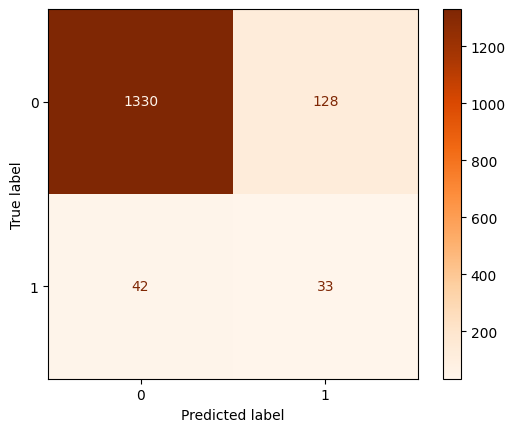

In [68]:
best_gb = grid_gb.best_estimator_
y_pred_gb = best_gb.predict(X_test)


print(f"Parametry: {grid_gb.best_params_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_gb):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb, cmap='Oranges')
plt.show()

Accuracy: 0.9302
Recall: 0.2000

Macierz pomyłek:


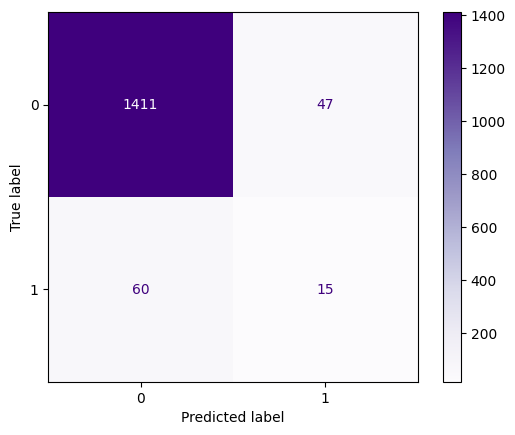

In [69]:
xgb_resampled = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_resampled.fit(X_resampled, y_resampled)
y_pred_xgb = xgb_resampled.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, cmap='Purples')
plt.show()


Najlepsze parametry: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
Accuracy: 0.8076
Recall: 0.6533

Macierz pomyłek:


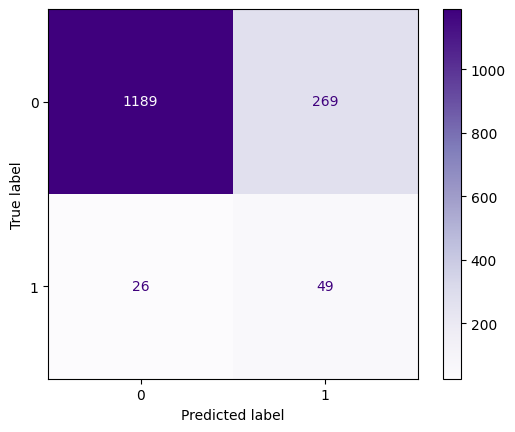

In [70]:
param_grid_xgb = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}


grid_xgb = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid_xgb,
    cv=3,
    scoring='recall',
    n_jobs=-1
)

grid_xgb.fit(X_resampled, y_resampled)


best_xgb = grid_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)


print(f"Najlepsze parametry: {grid_xgb.best_params_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best_xgb):.4f}")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best_xgb, cmap='Purples')
plt.show()


Recall: 0.7867
Accuracy: 0.6986


<Figure size 600x500 with 0 Axes>

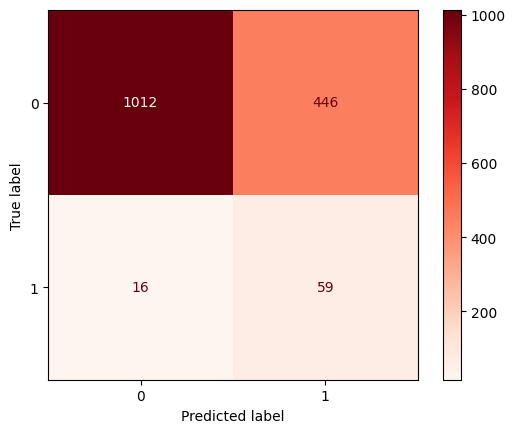

In [78]:
y_probs_xgb = best_xgb.predict_proba(X_test)[:, 1]
custom_threshold = 0.35
y_pred_custom = (y_probs_xgb >= custom_threshold).astype(int)

print(f"Recall: {recall_score(y_test, y_pred_custom):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_custom):.4f}")


plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_custom, cmap='Reds')
plt.show()

In [74]:
def predict_stroke_risk(new_data, model, threshold=0.35):


    df_input = new_data.copy()
    if 'id' in df_input.columns:
        df_input = df_input.drop(columns=['id'])

    bmi_median = data['bmi'].median()
    df_input['bmi'] = df_input['bmi'].fillna(bmi_median)
    df_encoded = pd.get_dummies(df_input, columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'], drop_first=True)

    for col in X.columns:
        if col not in df_encoded.columns:
            df_encoded[col] = 0


    df_encoded = df_encoded[X.columns]
    prob = model.predict_proba(df_encoded)[:, 1]
    prediction = (prob >= threshold).astype(int)

    return {
        'prawdopodobienstwo': prob[0],
        'wynik': "RYZYKO UDARU" if prediction[0] == 1 else "BRAK RYZYKA"
    }


In [76]:
sample_patient = pd.DataFrame([{
    'gender': 'Male',
    'age': 65.0,
    'hypertension': 0,
    'heart_disease': 1,
    'ever_married': 'Yes',
    'work_type': 'Private',
    'Residence_type': 'Urban',
    'avg_glucose_level': 228.69,
    'bmi': 36.6,
    'smoking_status': 'formerly smoked'
}])

result = predict_stroke_risk(sample_patient, best_xgb, threshold=0.35)
print(f"Pacjent testowy: {result['wynik']} (Prawdopodobieństwo: {result['prawdopodobienstwo']:.2%})")

Pacjent testowy: RYZYKO UDARU (Prawdopodobieństwo: 67.16%)


In [81]:
features = X.columns
importances = best_xgb.feature_importances_

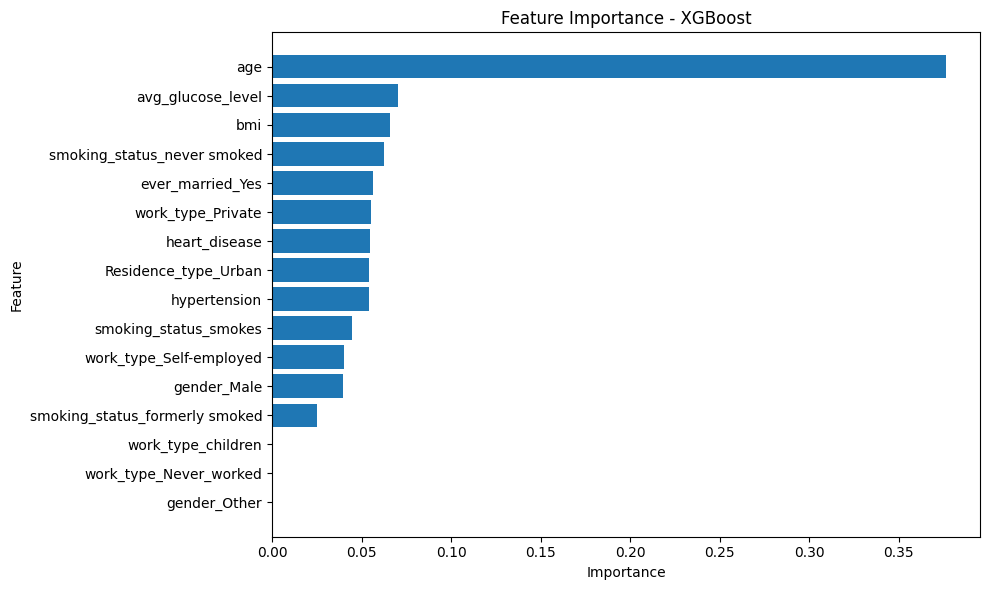

In [82]:
feat_imp = pd.DataFrame({
    'feature': features,
    'importance': importances
})

feat_imp = feat_imp.sort_values(by='importance', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()